Features after correlation filter: 539
=== Feature count tuning (using best architecture: 128→64→32) ===

  N_FEATURES= 50 -> CV ROC-AUC: 0.8593 ± 0.0513
  N_FEATURES= 75 -> CV ROC-AUC: 0.8698 ± 0.0541
  N_FEATURES=100 -> CV ROC-AUC: 0.8682 ± 0.0519
  N_FEATURES=125 -> CV ROC-AUC: 0.8432 ± 0.0564
  N_FEATURES=150 -> CV ROC-AUC: 0.8284 ± 0.0796
  N_FEATURES=200 -> CV ROC-AUC: 0.8463 ± 0.0706

>>> Best feature count: 75 (CV ROC-AUC: 0.8698)
Features after MI selection: 75
Class weights: {np.int64(0): np.float64(2.01), np.int64(1): np.float64(0.6655629139072847)}
Dummy baseline accuracy: 0.725
Train class distribution: {1: np.int64(453), 0: np.int64(150)}
Test class distribution: {1: np.int64(111), 0: np.int64(42)}

Config 1/8: {'hidden_units': (64, 32), 'activation': 'relu', 'dropout_rate': 0.4, 'l2_strength': 0.01, 'learning_rate': 0.0005, 'batch_size': 32, 'use_batch_norm': True}
  Fold 1: ROC-AUC = 0.902
  Fold 2: ROC-AUC = 0.846
  Fold 3: ROC-AUC = 0.839
  Fold 4: ROC-AUC = 0.796
  F

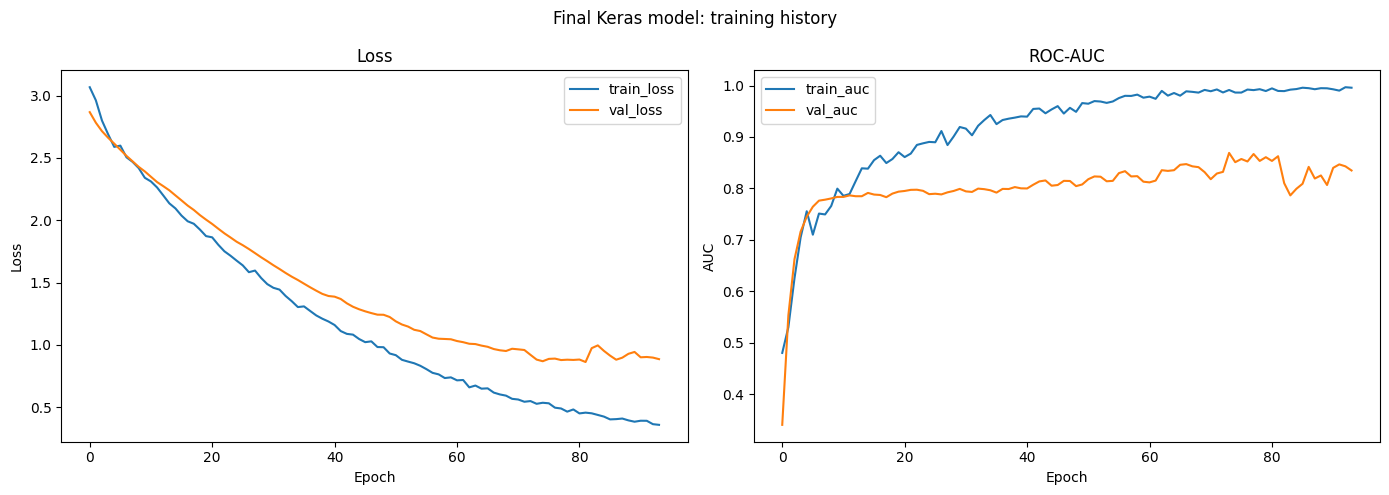

In [4]:
import pandas as pd
import numpy as np
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')

# ----------------------------
# 1. Reproducibility
# ----------------------------
def set_seeds(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(42)

df = pd.read_csv("pd_speech_features.csv", skiprows=1)

# ----------------------------
# 2. Split variables
# ----------------------------
X = df.drop(columns=["class", "id"])
y = df["class"]
groups = df["id"]

# ----------------------------
# 3. Grouped train/test split
# ----------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
train_groups = groups.iloc[train_idx].copy()

# ----------------------------
# 4. Correlation filter (fit only on training set)
# ----------------------------
corr = X_train.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.96)]

X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)

print(f"Features after correlation filter: {X_train.shape[1]}")

# ----------------------------
# 5. Feature selection: find optimal number via CV
# ----------------------------
feature_counts_to_test = [50, 75, 100, 125, 150, 200]
best_n_features = None
best_feature_auc = 0

print("=== Feature count tuning (using best architecture: 128→64→32) ===\n")

for n_feat in feature_counts_to_test:
    selector_temp = SelectKBest(mutual_info_classif, k=n_feat)
    selector_temp.fit(X_train, y_train)
    X_train_temp = pd.DataFrame(
        selector_temp.transform(X_train),
        columns=X_train.columns[selector_temp.get_support()],
        index=X_train.index
    )

    group_kfold_temp = GroupKFold(n_splits=5)
    fold_aucs = []

    for fold, (tr_idx, val_idx) in enumerate(group_kfold_temp.split(X_train_temp, y_train, train_groups), start=1):
        X_tr = X_train_temp.iloc[tr_idx]
        X_val = X_train_temp.iloc[val_idx]
        y_tr = y_train.iloc[tr_idx]
        y_val = y_train.iloc[val_idx]

        scaler_temp = StandardScaler()
        X_tr_scaled = scaler_temp.fit_transform(X_tr)
        X_val_scaled = scaler_temp.transform(X_val)

        set_seeds(42 + fold)
        tf.keras.backend.clear_session()

        model_temp = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(n_feat,)),
            tf.keras.layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation("relu"),
            tf.keras.layers.Dropout(0.4),
            tf.keras.layers.Dense(64, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation("relu"),
            tf.keras.layers.Dropout(0.4),
            tf.keras.layers.Dense(32, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation("relu"),
            tf.keras.layers.Dropout(0.4),
            tf.keras.layers.Dense(1, activation="sigmoid"),
        ])

        model_temp.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
            loss="binary_crossentropy",
            metrics=[tf.keras.metrics.AUC(name="auc")]
        )

        model_temp.fit(
            X_tr_scaled, y_tr,
            validation_data=(X_val_scaled, y_val),
            epochs=200, batch_size=32,
            class_weight=class_weight,
            callbacks=[tf.keras.callbacks.EarlyStopping(
                monitor="val_auc", mode="max", patience=15, restore_best_weights=True
            ), tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6
            )],
            verbose=0
        )

        val_proba = model_temp.predict(X_val_scaled, verbose=0).ravel()
        fold_aucs.append(roc_auc_score(y_val, val_proba))

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)
    print(f"  N_FEATURES={n_feat:>3d} -> CV ROC-AUC: {mean_auc:.4f} ± {std_auc:.4f}")

    if mean_auc > best_feature_auc:
        best_feature_auc = mean_auc
        best_n_features = n_feat

print(f"\n>>> Best feature count: {best_n_features} (CV ROC-AUC: {best_feature_auc:.4f})")

# Apply the best feature selection
selector = SelectKBest(mutual_info_classif, k=best_n_features)
selector.fit(X_train, y_train)

X_train = pd.DataFrame(
    selector.transform(X_train),
    columns=X_train.columns[selector.get_support()],
    index=X_train.index
)
X_test = pd.DataFrame(
    selector.transform(X_test),
    columns=X_test.columns[selector.get_support()],
    index=X_test.index
)

print(f"Features after MI selection: {X_train.shape[1]}")

# ----------------------------
# 6. Compute class weights (dataset is imbalanced)
# ----------------------------
classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))
print(f"Class weights: {class_weight}")

# ----------------------------
# 7. Dummy baseline
# ----------------------------
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
print(f"Dummy baseline accuracy: {dummy.score(X_test, y_test):.3f}")
print(f"Train class distribution: {dict(y_train.value_counts())}")
print(f"Test class distribution: {dict(y_test.value_counts())}")

# ----------------------------
# 8. Keras model builder (with batch normalisation)
# ----------------------------
def build_keras_model(
    input_dim,
    hidden_units,
    activation="relu",
    dropout_rate=0.3,
    l2_strength=1e-3,
    learning_rate=5e-4,
    use_batch_norm=True
):
    tf.keras.backend.clear_session()

    regularizer = tf.keras.regularizers.l2(l2_strength) if l2_strength > 0 else None

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_dim,)))

    for units in hidden_units:
        model.add(tf.keras.layers.Dense(units, kernel_regularizer=regularizer))
        if use_batch_norm:
            model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Activation(activation))
        if dropout_rate > 0:
            model.add(tf.keras.layers.Dropout(dropout_rate))

    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
    )

    return model

# ----------------------------
# 9. Search space (stronger regularisation, batch norm)
# ----------------------------
search_space = [
    {
        "hidden_units": (64, 32),
        "activation": "relu",
        "dropout_rate": 0.4,
        "l2_strength": 1e-2,
        "learning_rate": 5e-4,
        "batch_size": 32,
        "use_batch_norm": True
    },
    {
        "hidden_units": (64, 32),
        "activation": "relu",
        "dropout_rate": 0.5,
        "l2_strength": 1e-2,
        "learning_rate": 1e-3,
        "batch_size": 32,
        "use_batch_norm": True
    },
    {
        "hidden_units": (128, 64),
        "activation": "relu",
        "dropout_rate": 0.4,
        "l2_strength": 1e-2,
        "learning_rate": 5e-4,
        "batch_size": 32,
        "use_batch_norm": True
    },
    {
        "hidden_units": (128, 64, 32),
        "activation": "relu",
        "dropout_rate": 0.4,
        "l2_strength": 1e-2,
        "learning_rate": 5e-4,
        "batch_size": 32,
        "use_batch_norm": True
    },
    {
        "hidden_units": (64, 32),
        "activation": "selu",
        "dropout_rate": 0.3,
        "l2_strength": 1e-2,
        "learning_rate": 5e-4,
        "batch_size": 32,
        "use_batch_norm": False
    },
    {
        "hidden_units": (128, 64),
        "activation": "selu",
        "dropout_rate": 0.3,
        "l2_strength": 1e-2,
        "learning_rate": 5e-4,
        "batch_size": 32,
        "use_batch_norm": False
    },
    {
        "hidden_units": (64, 32),
        "activation": "relu",
        "dropout_rate": 0.5,
        "l2_strength": 5e-2,
        "learning_rate": 1e-3,
        "batch_size": 64,
        "use_batch_norm": True
    },
    {
        "hidden_units": (32, 16),
        "activation": "relu",
        "dropout_rate": 0.3,
        "l2_strength": 1e-2,
        "learning_rate": 1e-3,
        "batch_size": 32,
        "use_batch_norm": True
    },
]

# ----------------------------
# 10. Grouped CV evaluation
# ----------------------------
group_kfold = GroupKFold(n_splits=5)
results = []

for i, config in enumerate(search_space, start=1):
    fold_aucs = []

    print(f"\nConfig {i}/{len(search_space)}: {config}")

    for fold, (tr_idx, val_idx) in enumerate(group_kfold.split(X_train, y_train, train_groups), start=1):
        X_tr = X_train.iloc[tr_idx].copy()
        X_val = X_train.iloc[val_idx].copy()
        y_tr = y_train.iloc[tr_idx].copy()
        y_val = y_train.iloc[val_idx].copy()

        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_val_scaled = scaler.transform(X_val)

        set_seeds(42 + fold)

        model = build_keras_model(
            input_dim=X_tr_scaled.shape[1],
            hidden_units=config["hidden_units"],
            activation=config["activation"],
            dropout_rate=config["dropout_rate"],
            l2_strength=config["l2_strength"],
            learning_rate=config["learning_rate"],
            use_batch_norm=config["use_batch_norm"]
        )

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=15,
            restore_best_weights=True
        )

        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=7,
            min_lr=1e-6
        )

        history = model.fit(
            X_tr_scaled,
            y_tr,
            validation_data=(X_val_scaled, y_val),
            epochs=200,
            batch_size=config["batch_size"],
            class_weight=class_weight,
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )

        val_proba = model.predict(X_val_scaled, verbose=0).ravel()
        fold_auc = roc_auc_score(y_val, val_proba)
        fold_aucs.append(fold_auc)

        print(f"  Fold {fold}: ROC-AUC = {fold_auc:.3f}")

    result = {
        **config,
        "cv_auc_mean": float(np.mean(fold_aucs)),
        "cv_auc_std": float(np.std(fold_aucs))
    }
    results.append(result)

    print(f"  -> Mean CV ROC-AUC: {result['cv_auc_mean']:.3f} ± {result['cv_auc_std']:.3f}")

# ----------------------------
# 11. Collect results
# ----------------------------
results_df = pd.DataFrame(results).sort_values("cv_auc_mean", ascending=False)

print("\nTop configurations:")
print(results_df[[
    "hidden_units", "activation", "dropout_rate",
    "l2_strength", "learning_rate", "batch_size",
    "use_batch_norm", "cv_auc_mean", "cv_auc_std"
]].to_string())

best_config = results_df.iloc[0].to_dict()
print("\nBest config:")
print(best_config)

# ----------------------------
# 12. Retrain best model on full training set
# ----------------------------
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled = scaler_final.transform(X_test)

set_seeds(42)

best_model = build_keras_model(
    input_dim=X_train_scaled.shape[1],
    hidden_units=best_config["hidden_units"],
    activation=best_config["activation"],
    dropout_rate=best_config["dropout_rate"],
    l2_strength=best_config["l2_strength"],
    learning_rate=best_config["learning_rate"],
    use_batch_norm=best_config["use_batch_norm"]
)

early_stop_final = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=20,
    restore_best_weights=True
)

reduce_lr_final = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-6
)

history = best_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.15,
    epochs=300,
    batch_size=int(best_config["batch_size"]),
    class_weight=class_weight,
    callbacks=[early_stop_final, reduce_lr_final],
    verbose=1
)

# ----------------------------
# 13. Test evaluation
# ----------------------------
test_proba = best_model.predict(X_test_scaled, verbose=0).ravel()
test_pred_05 = (test_proba >= 0.5).astype(int)

print("\nTest set results at threshold 0.5")
print(classification_report(y_test, test_pred_05))
print("Confusion matrix:")
print(confusion_matrix(y_test, test_pred_05))
print(f"Test ROC-AUC: {roc_auc_score(y_test, test_proba):.3f}")

# ----------------------------
# 14. Threshold tuning on test set (exploratory)
# ----------------------------
print("\n--- Threshold analysis ---")
for t in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]:
    pred_t = (test_proba >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, pred_t))

# ----------------------------
# 15. Plot training history of final model
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="train_loss")
axes[0].plot(history.history["val_loss"], label="val_loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["auc"], label="train_auc")
axes[1].plot(history.history["val_auc"], label="val_auc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].set_title("ROC-AUC")
axes[1].legend()

plt.suptitle("Final Keras model: training history")
plt.tight_layout()
plt.show()